###EDA


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/listings_clean(1).csv")

df.head()

,id,name,host_id,host_name,host_since,host_response_time,host_response_rate,host_is_superhost,neighbourhood_cleansed,neighbourhood_group_cleansed,...,bedrooms,beds,price,minimum_nights,availability_365,number_of_reviews,review_scores_rating,instant_bookable,host_never_responded,license_status
0,670339032744709144,Westwood lovely three bedrooms three bathrooms,4780152,Moon,2013-01-20,within a few hours,0.96,False,West Los Angeles,City of Los Angeles,...,3.0,3.0,399.0,30,365,0,NaN,False,False,none
1,1024835174766068422,Charming Beverly Hills Home,513813179,Tiana,2023-05-08,within a day,0.60,False,Beverly Hills,Other Cities,...,3.0,3.0,434.0,30,267,0,NaN,False,False,none
2,850744632375448560,Tianpu's warm room with bathroom,432956623,Dan,2021-11-22,a few days or more,0.20,False,Temple City,Other Cities,...,1.0,1.0,49.0,1,364,1,3.00,False,False,none
3,953950676345326970,"Santa Monica apt, free parking, steps to the b...",528669205,Farkhat,2023-07-29,within an hour,1.00,True,Santa Monica,Other Cities,...,0.0,1.0,231.0,5,193,44,4.93,True,False,exempt
4,1082614257267236225,Practical Private Room #1398 A,557999481,Christos,2024-01-22,within a day,1.00,False,North Hollywood,City of Los Angeles,...,4.0,1.0,62.0,30,278,0,NaN,False,False,none


In [ ]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37296 entries, 0 to 37295
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            37296 non-null  int64  
 1   name                          37296 non-null  object 
 2   host_id                       37296 non-null  int64  
 3   host_name                     37296 non-null  object 
 4   host_since                    37296 non-null  object 
 5   host_response_time            33026 non-null  object 
 6   host_response_rate            33026 non-null  float64
 7   host_is_superhost             36141 non-null  object 
 8   neighbourhood_cleansed        37296 non-null  object 
 9   neighbourhood_group_cleansed  37296 non-null  object 
 10  latitude                      37296 non-null  float64
 11  longitude                     37296 non-null  float64
 12  property_type                 37296 non-null  object 
 13  r

,id,host_id,host_response_rate,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,availability_365,number_of_reviews,review_scores_rating
count,3.729600e+04,3.729600e+04,33026.000000,37296.000000,37296.000000,37296.000000,37284.000000,37151.000000,36390.000000,37296.000000,37296.000000,37296.000000,37296.000000,28132.000000
mean,5.895774e+17,2.070818e+08,0.952964,34.056152,-118.313287,4.174174,1.649582,1.778929,2.305551,289.377762,16.142428,231.080143,40.965975,4.783280
std,4.929287e+17,1.950934e+08,0.166997,0.145493,0.173855,2.922884,1.218518,1.361510,1.799765,715.366985,21.030276,112.658666,85.594459,0.409133
min,1.090000e+02,5.210000e+02,0.000000,33.338360,-118.917134,1.000000,0.000000,0.000000,1.000000,5.000000,1.000000,0.000000,0.000000,1.000000
25%,4.230061e+07,2.866160e+07,1.000000,33.999355,-118.414812,2.000000,1.000000,1.000000,1.000000,98.000000,2.000000,136.750000,1.000000,4.750000
50%,7.428982e+17,1.295063e+08,1.000000,34.060567,-118.344060,4.000000,1.000000,1.000000,2.000000,155.000000,5.000000,255.000000,7.000000,4.900000
75%,1.051055e+18,4.015386e+08,1.000000,34.110221,-118.228475,6.000000,2.000000,2.000000,3.000000,260.000000,30.000000,344.000000,41.000000,5.000000
max,1.238217e+18,5.997497e+08,1.000000,34.811183,-117.653352,16.000000,50.000000,50.000000,50.000000,56425.000000,700.000000,365.000000,3024.000000,5.000000


### Data Overview and Initial Screening

The cleaned Los Angeles Airbnb dataset contains 37,296 listings and 26 variables. The dataset includes a mixture of numerical, categorical, and boolean features. The dataset covers listing characteristics, host information, geographic location, property type, room type, availability, reviews, and price.

The target dependent variable for our research is `price`, which is a continuous variable. Summary statistics show that price is highly right-skewed. While the median listing price is 155 dollars, the mean price is approximately 289 dollars, and the maximum price reaches 56,425 dollars. This suggests that a small number of extremely expensive listings may strongly influence the price distribution. Therefore, the following EDA will examine both the raw price distribution and the log-transformed price distribution.

Most variables are complete, but several features contain missing values. The largest amount of missing data appears in `review_scores_rating`, followed by `host_response_rate`, `host_response_time`, `host_is_superhost`, `beds`, `bedrooms`, and `bathrooms`. These missing values need to be handled before modeling. In particular, missing review scores may reflect new or rarely reviewed listings rather than random missings.

In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

,0
review_scores_rating,9164
host_response_rate,4270
host_response_time,4270
host_is_superhost,1155
beds,906
bedrooms,145
bathrooms,12


1. Price Distribution

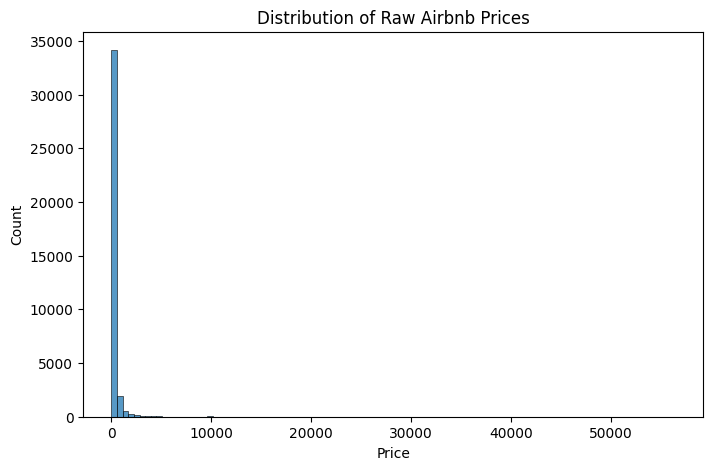

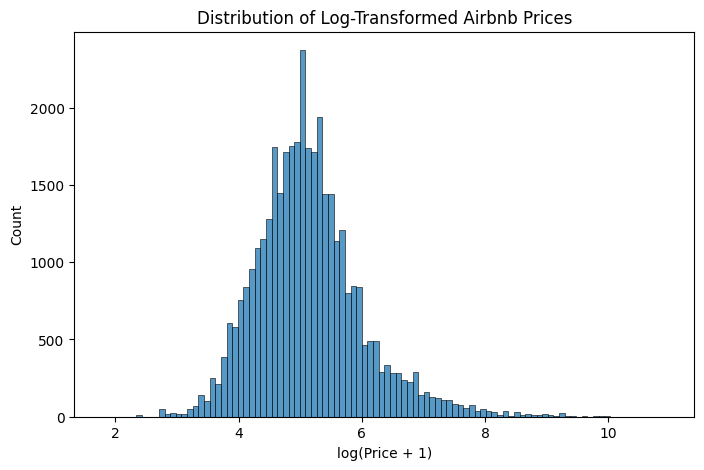

In [ ]:
df["log_price"] = np.log1p(df["price"])

plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=100)
plt.title("Distribution of Raw Airbnb Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df["log_price"], bins=100)
plt.title("Distribution of Log-Transformed Airbnb Prices")
plt.xlabel("log(Price + 1)")
plt.ylabel("Count")
plt.show()

The target variable `price` is highly right-skewed, indicating that most listings are relatively affordable while a small number of luxury or unusual listings have extremely high prices. The log-transformed distribution is more symmetric, so we use `log(price + 1)` in later visualizations to better examine relationships between price and listing characteristics.

## 1. Listing Capacity VS Price
In this section, listing capacity refers to the physical size and guest capacity of a listing, including `accommodates`, `bathrooms`, `bedrooms`, and `beds`. These variables are expected to be directly related to price because larger listings can host more guests and provide more space and amenities.

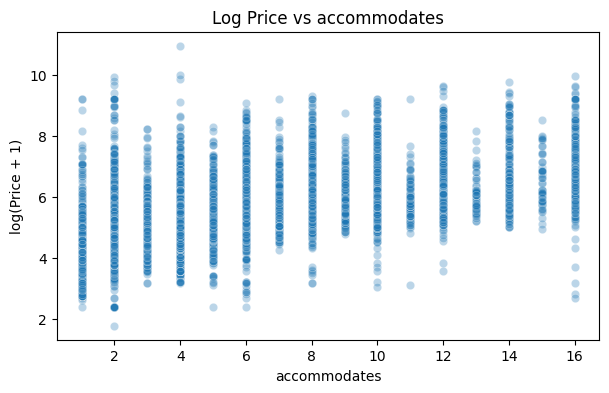

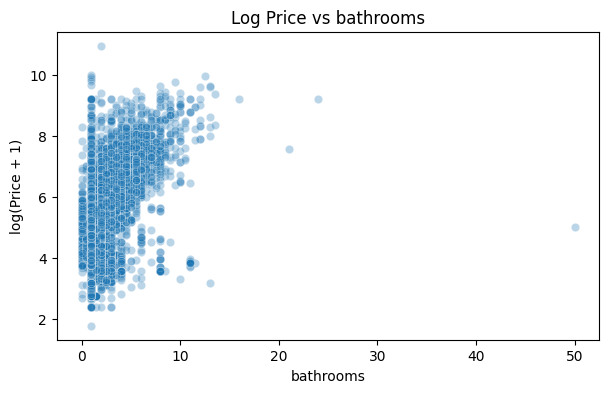

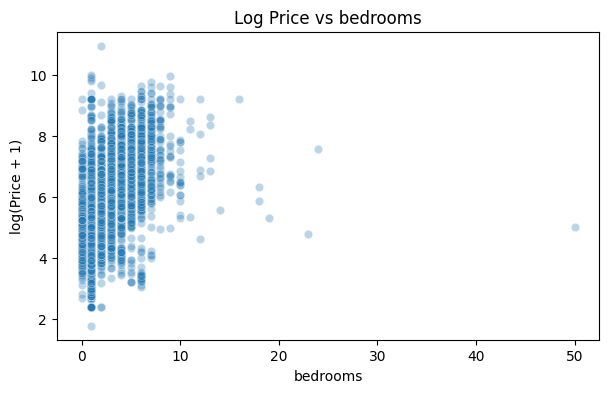

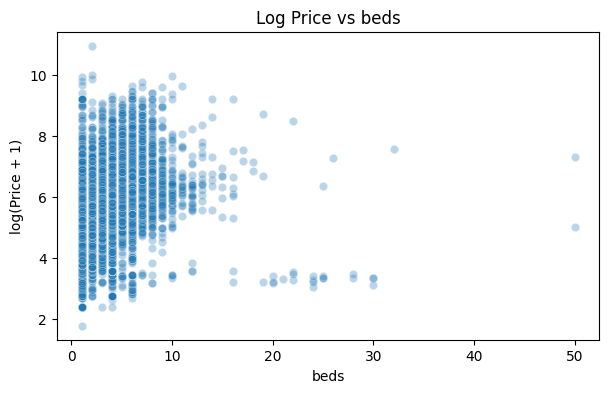

In [ ]:
capacity_cols = ["accommodates", "bathrooms", "bedrooms", "beds"]

for col in capacity_cols:
    plt.figure(figsize=(7,4))
    sns.scatterplot(data=df, x=col, y="log_price", alpha=0.3)
    plt.title(f"Log Price vs {col}")
    plt.xlabel(col)
    plt.ylabel("log(Price + 1)")
    plt.show()

The scatterplots suggest that listing capacity is generally positively associated with log price. Listings that accommodate more guests, or have more bathrooms, bedrooms, and beds, tend to appear in higher log-price ranges. This supports the intuition that larger listings can host more guests and therefore charge higher prices.

However, the relationship is not perfectly linear. There is substantial price variation within the same capacity level, especially for common values such as 2 to 6 guests or 1 to 3 bedrooms. This suggests that capacity alone cannot fully explain Airbnb listing prices. Other factors, such as location, room type, property type, host characteristics, and review-related features, are also likely to affect prices.

The plots also reveal several extreme values, such as listings with unusually large numbers of bathrooms, bedrooms, or beds. These observations may represent luxury properties, large shared accommodations, or potential data anomalies.

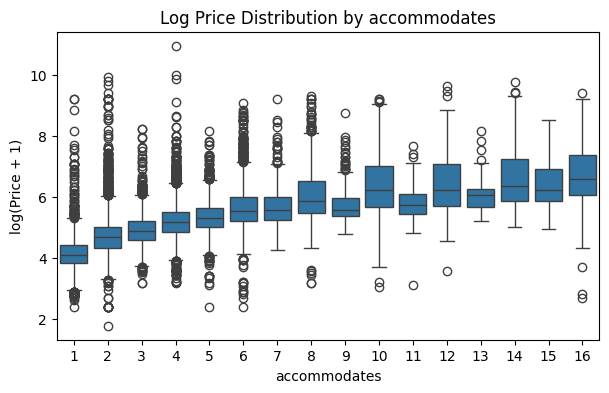

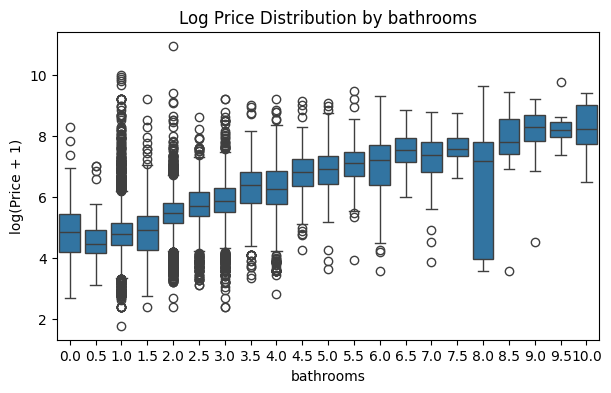

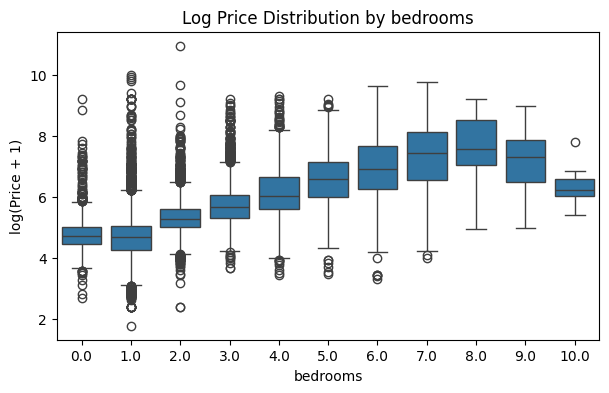

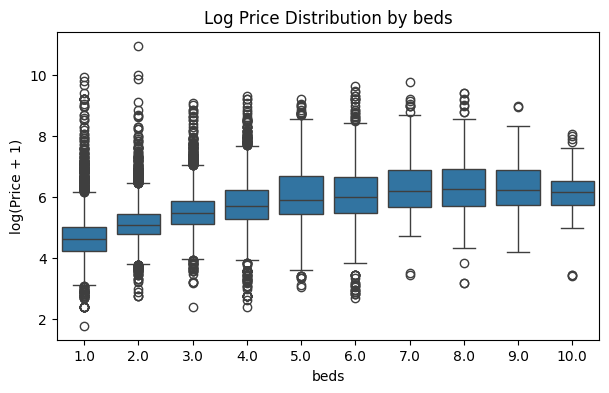

In [ ]:
# Filter extreme capacity values to make the main pattern easier to visualize
df_capacity_filtered = df[
    (df["accommodates"] <= 16) &
    (df["bathrooms"] <= 10) &
    (df["bedrooms"] <= 10) &
    (df["beds"] <= 10)
].copy()

capacity_cols = ["accommodates", "bathrooms", "bedrooms", "beds"]

for col in capacity_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df_capacity_filtered, x=col, y="log_price")
    plt.title(f"Log Price Distribution by {col}")
    plt.xlabel(col)
    plt.ylabel("log(Price + 1)")
    plt.show()

After we filtered the extremes, the boxplots now show a clear positive relationship between listing capacity and log-transformed price. Similar upward patterns can also be observed for bathrooms, bedrooms, and beds, suggesting that larger listings tend to charge higher prices.

Still, capacity alone cannot fully explain Airbnb listing prices. Other factors such as location, room type, property type, host characteristics, and review-related variables are also likely to influence price.

## 2. Room Type VS Price

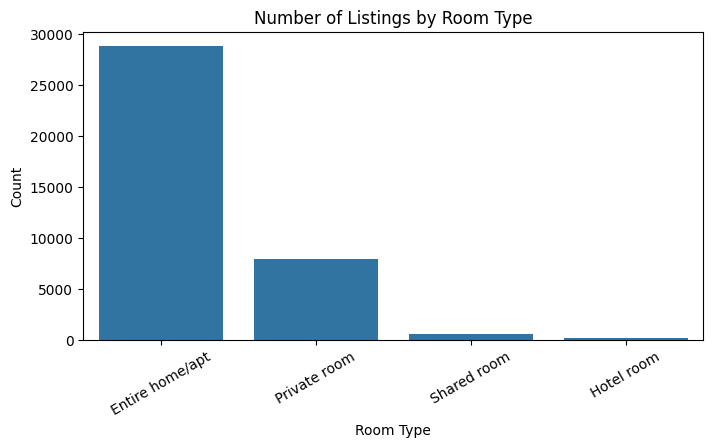

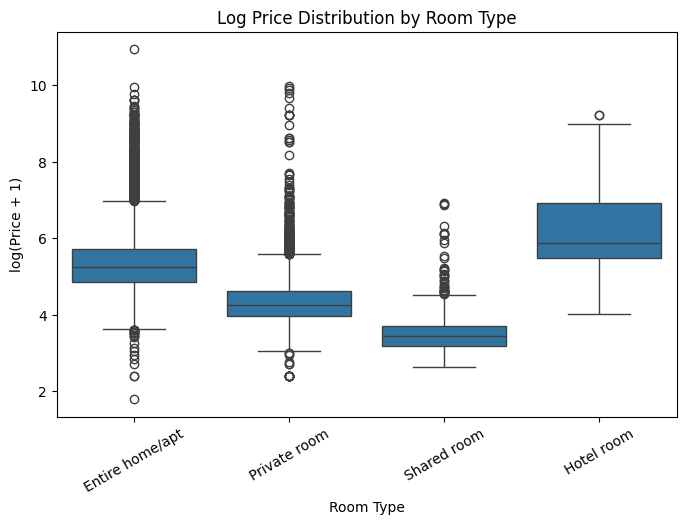

,listing_count,median_price,mean_price,median_log_price
room_type,,,,
Hotel room,116,355.0,891.465517,5.874832
Entire home/apt,28789,186.0,337.884921,5.231109
Private room,7885,70.0,118.853773,4.262680
Shared room,506,30.0,48.798419,3.433987


In [ ]:
room_counts = df["room_type"].value_counts()
room_counts

plt.figure(figsize=(8,4))
sns.countplot(
    data=df,
    x="room_type",
    order=df["room_type"].value_counts().index
)
plt.title("Number of Listings by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="room_type",
    y="log_price",
    order=df["room_type"].value_counts().index
)
plt.title("Log Price Distribution by Room Type")
plt.xlabel("Room Type")
plt.ylabel("log(Price + 1)")
plt.xticks(rotation=30)
plt.show()

room_summary = (
    df.groupby("room_type")
    .agg(
        listing_count=("price", "count"),
        median_price=("price", "median"),
        mean_price=("price", "mean"),
        median_log_price=("log_price", "median")
    )
    .sort_values(by="median_price", ascending=False)
)

room_summary


Room type shows a clear relationship with Airbnb listing prices. The median price differs substantially across the four room types. Hotel rooms have the highest median price at 355 USD. The entire homes/apartments is at 186 USD. The private rooms are at 70 USD, and the shared rooms are at $30.

This pattern suggests that privacy and the level of space offered to guests are strongly associated with price. Entire homes/apartments are more expensive than private or shared rooms because guests have access to the full property. Shared rooms have the lowest median price, which is consistent with their lower level of privacy and space.

However, the number of listings is highly imbalanced across room types. Entire homes/apartments dominate the dataset with 28,789 listings, while hotel rooms only have 116 listings. Therefore, although hotel rooms have the highest median price, this category should be interpreted carefully because it represents a much smaller portion of the dataset.

Overall, room type appears to be an important factor influencing Airbnb prices in Los Angeles and should be included as a categorical feature in later modeling and unsupervised learning.

##3. Property Type VS Price

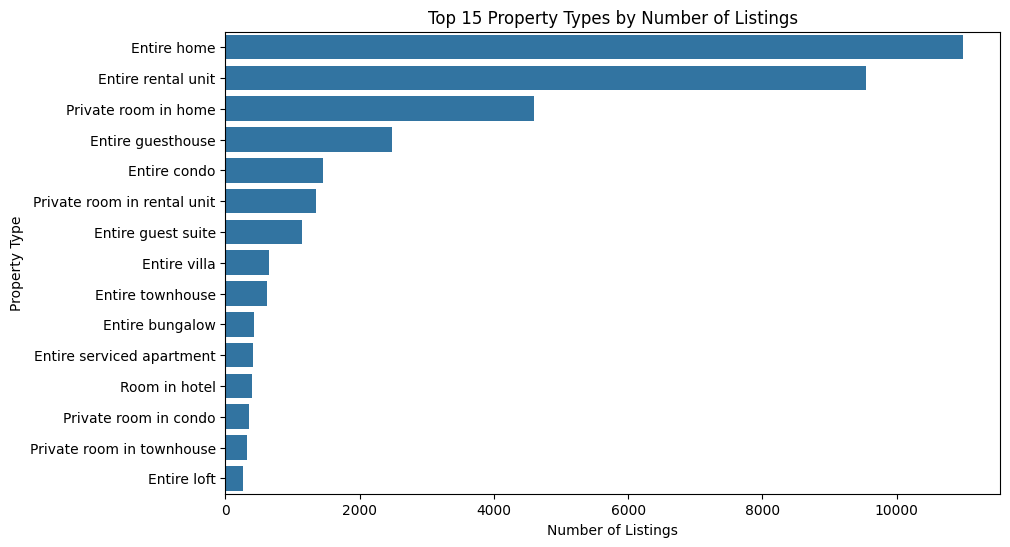

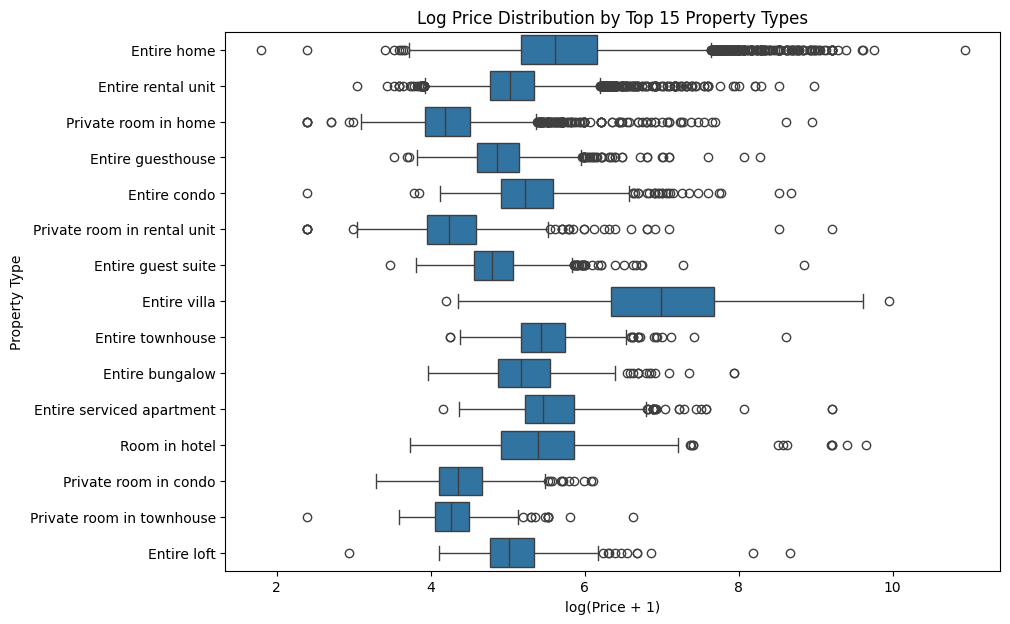

,listing_count,median_price,mean_price,median_log_price
property_type,,,,
Entire villa,644,1080.0,1834.321429,6.985642
Entire home,10995,275.0,471.738881,5.620401
Entire serviced apartment,405,233.0,362.276543,5.455321
Entire townhouse,625,229.0,275.270400,5.438079
Room in hotel,400,219.0,479.155000,5.393628
Entire condo,1449,185.0,240.199448,5.225747
Entire bungalow,429,176.0,229.925408,5.176150
Entire rental unit,9539,152.0,183.465772,5.030438
Entire loft,267,150.0,216.790262,5.017280


In [ ]:
top_property_types = df["property_type"].value_counts().head(15)

plt.figure(figsize=(10,6))
sns.barplot(
    x=top_property_types.values,
    y=top_property_types.index
)
plt.title("Top 15 Property Types by Number of Listings")
plt.xlabel("Number of Listings")
plt.ylabel("Property Type")
plt.show()

top_property_list = top_property_types.index
df_top_property = df[df["property_type"].isin(top_property_list)].copy()

plt.figure(figsize=(10,7))
sns.boxplot(
    data=df_top_property,
    y="property_type",
    x="log_price",
    order=top_property_list
)
plt.title("Log Price Distribution by Top 15 Property Types")
plt.xlabel("log(Price + 1)")
plt.ylabel("Property Type")
plt.show()

property_summary = (
    df_top_property.groupby("property_type")
    .agg(
        listing_count=("price", "count"),
        median_price=("price", "median"),
        mean_price=("price", "mean"),
        median_log_price=("log_price", "median")
    )
    .sort_values(by="median_price", ascending=False)
)

property_summary

The boxplot shows that property type is clearly associated with Airbnb listing prices. Different property types have noticeably different median log prices. Entire villas have the highest price distribution among the top property types, which is consistent with their larger space, greater privacy, and more premium guest experience.

Entire homes, serviced apartments, townhouses, condos, and hotel rooms also tend to have higher prices than private-room property types. In contrast, private rooms in homes, rental units, condos, or townhouses generally have lower log prices. This pattern suggests that property types offering more private space and full-unit access are associated with higher prices.

The plot also shows many high-price outliers within several property types, especially entire homes and entire rental units. This suggests that even within the same property type, prices can vary widely, likely due to differences in location, capacity, amenities, and host quality.

Overall, property type is an important categorical factor for understanding Airbnb prices, but it should be interpreted together with room type, listing capacity, and location.

## 4. Location and Price

Neighborhood Group VS Log Price

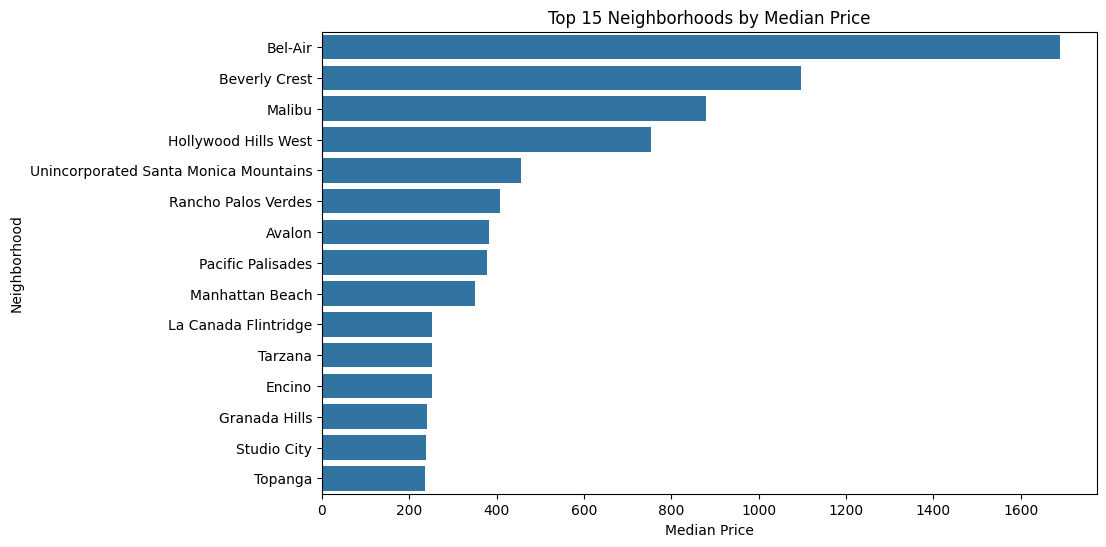

,Neighborhood,Listing Count,Median Price,Mean Price,Median Log Price
0,Bel-Air,73,1690.0,2680.753425,7.433075
1,Beverly Crest,187,1098.0,1521.540107,7.002156
2,Malibu,411,879.0,1652.170316,6.779922
3,Hollywood Hills West,564,754.5,1144.069149,6.627362
4,Unincorporated Santa Monica Mountains,176,455.5,698.301136,6.123583
5,Rancho Palos Verdes,96,407.0,899.468750,6.011120
6,Avalon,210,382.0,440.614286,5.948021
7,Pacific Palisades,158,379.0,587.860759,5.940157
8,Manhattan Beach,345,350.0,462.034783,5.860786
9,La Canada Flintridge,36,253.0,331.777778,5.535587


In [ ]:
neigh_summary = (
    df.groupby("neighbourhood_cleansed")
    .agg(
        listing_count=("price", "count"),
        median_price=("price", "median"),
        mean_price=("price", "mean"),
        median_log_price=("log_price", "median")
    )
    .sort_values(by="median_price", ascending=False)
)

neigh_summary_filtered = neigh_summary[neigh_summary["listing_count"] >= 30]

top_neigh_price = (
    neigh_summary_filtered
    .sort_values(by="median_price", ascending=False)
    .head(15)
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_neigh_price.reset_index(),
    x="median_price",
    y="neighbourhood_cleansed"
)
plt.title("Top 15 Neighborhoods by Median Price")
plt.xlabel("Median Price")
plt.ylabel("Neighborhood")
plt.show()

top15_neighborhood_summary = top_neigh_price.copy()
top15_neighborhood_summary_table = (
    top15_neighborhood_summary
    .reset_index()
    .rename(columns={
        "neighbourhood_cleansed": "Neighborhood",
        "listing_count": "Listing Count",
        "median_price": "Median Price",
        "mean_price": "Mean Price",
        "median_log_price": "Median Log Price"
    })
)

top15_neighborhood_summary_table



The neighborhood-level analysis shows substantial price differences across specific areas in Los Angeles. High-end neighborhoods such as Bel-Air, Beverly Crest, Malibu, and Hollywood Hills West have much higher median prices than most other neighborhoods.

These results support the idea that location is an important factor influencing Airbnb prices. Neighborhood-level price differences may reflect local demand, neighborhood reputation, tourism appeal, coastal or hillside location, and proximity to popular destinations.

Overall, `neighbourhood_cleansed` appears to be a useful categorical feature for later unsupervised learning and supervised price prediction.

##5. Host Characteristics and Price

In this section, we examine whether host-related features are associated with Airbnb listing prices. Host characteristics may capture trust, professionalism, responsiveness, and booking convenience. We focus on variables such as `host_is_superhost`, `host_response_time`, `host_response_rate`, `instant_bookable`, `host_never_responded`, and `license_status`.

5.1 Superhosts status

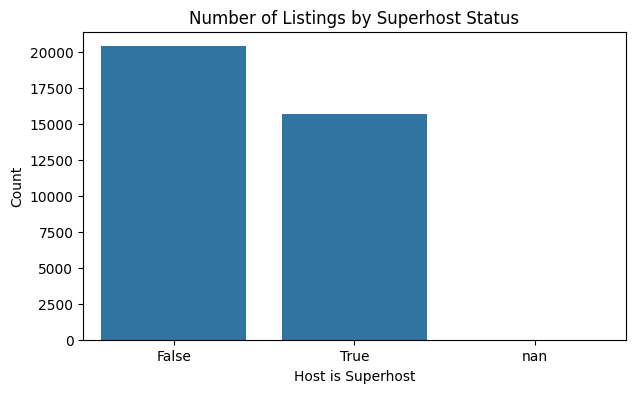

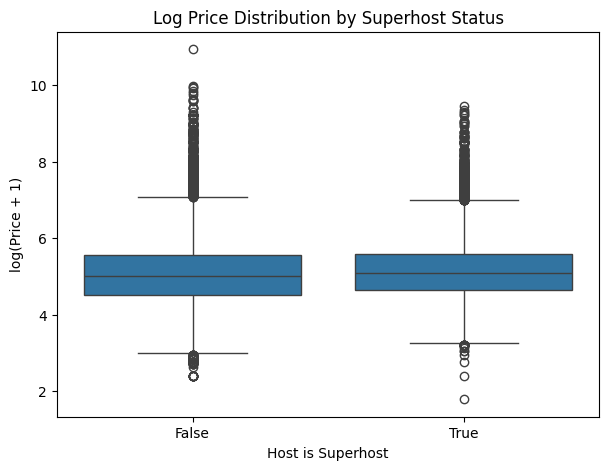

,listing_count,median_price,mean_price,median_log_price
host_is_superhost,,,,
True,15731,161.0,268.296866,5.087596
NaN,1155,161.0,241.119481,5.087596
False,20410,150.0,308.356786,5.017280


In [ ]:
df["host_is_superhost"].value_counts(dropna=False)

plt.figure(figsize=(7,4))
sns.countplot(
    data=df,
    x="host_is_superhost",
    order=df["host_is_superhost"].value_counts(dropna=False).index
)
plt.title("Number of Listings by Superhost Status")
plt.xlabel("Host is Superhost")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(7,5))
sns.boxplot(
    data=df,
    x="host_is_superhost",
    y="log_price"
)
plt.title("Log Price Distribution by Superhost Status")
plt.xlabel("Host is Superhost")
plt.ylabel("log(Price + 1)")
plt.show()

superhost_summary = (
    df.groupby("host_is_superhost", dropna=False)
    .agg(
        listing_count=("price", "count"),
        median_price=("price", "median"),
        mean_price=("price", "mean"),
        median_log_price=("log_price", "median")
    )
    .sort_values(by="median_price", ascending=False)
)

superhost_summary

Superhost status may reflect host reputation and service quality, but in this dataset it shows only a small difference in median price. Therefore, it may provide some additional information about listing quality, but it appears to be a weaker pricing factor than listing capacity, room type, property type, and neighborhood.

5.2 Host Response Time and Price

`host_response_time` describes how quickly a host typically responds to guest inquiries. Faster response time may indicate better host responsiveness and service quality. In this section, we examine whether listings with faster host response times tend to have different prices.

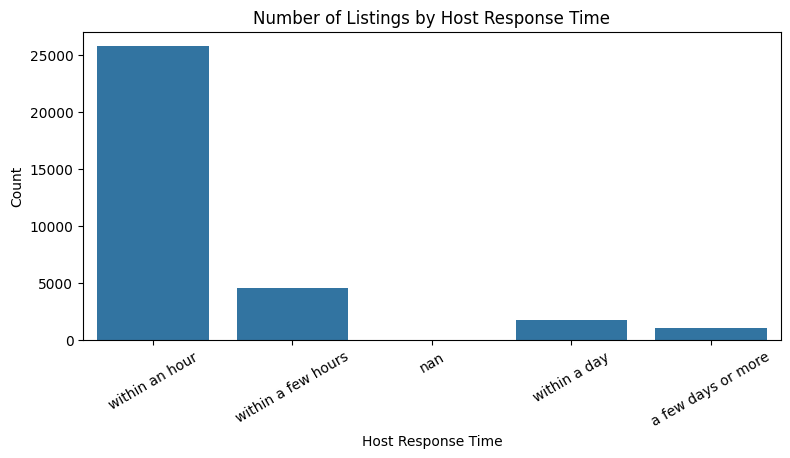

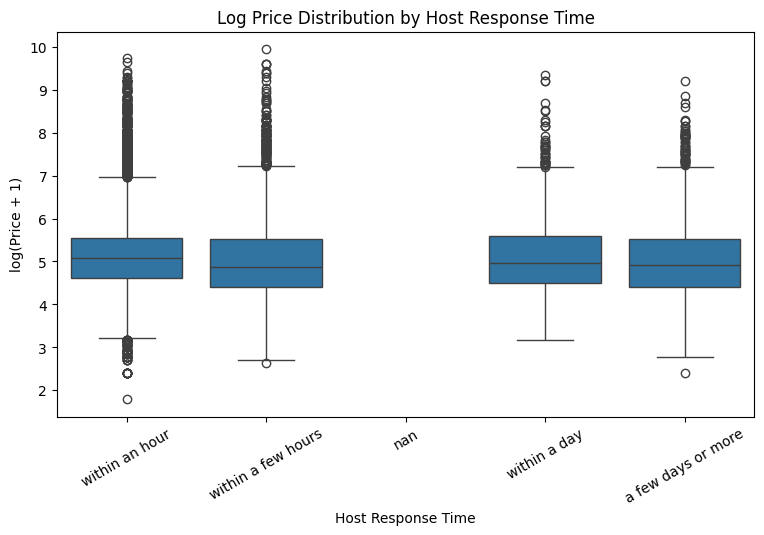

,listing_count,median_price,mean_price,median_log_price
host_response_time,,,,
NaN,4270,165.0,379.867447,5.111988
within an hour,25775,160.0,270.245276,5.081404
within a day,1737,143.0,284.407599,4.969813
a few days or more,1021,135.0,337.509305,4.912655
within a few hours,4493,131.0,304.120632,4.882802


In [ ]:
df["host_response_time"].value_counts(dropna=False)

plt.figure(figsize=(9,4))
sns.countplot(
    data=df,
    x="host_response_time",
    order=df["host_response_time"].value_counts(dropna=False).index
)
plt.title("Number of Listings by Host Response Time")
plt.xlabel("Host Response Time")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(9,5))
sns.boxplot(
    data=df,
    x="host_response_time",
    y="log_price",
    order=df["host_response_time"].value_counts(dropna=False).index
)
plt.title("Log Price Distribution by Host Response Time")
plt.xlabel("Host Response Time")
plt.ylabel("log(Price + 1)")
plt.xticks(rotation=30)
plt.show()

response_time_summary = (
    df.groupby("host_response_time", dropna=False)
    .agg(
        listing_count=("price", "count"),
        median_price=("price", "median"),
        mean_price=("price", "mean"),
        median_log_price=("log_price", "median")
    )
    .sort_values(by="median_price", ascending=False)
)

response_time_summary

Host response time shows a strong difference in listing counts. Most listings are hosted by hosts who respond within an hour, suggesting that fast response is common among active Airbnb hosts in Los Angeles.

However, the price differences across response-time categories are relatively small, suggested by both table and box plot.

This suggests that host response time may reflect host activity or service responsiveness, but it is not a strong direct driver of listing price. Compared with listing capacity, room type, property type, and neighborhood, response time appears to be a weaker pricing factor.

There are also missing values in `host_response_time`, which should be handled during preprocessing for later unsupervised learning and supervised modeling.

5.3 Instant Bookable and Price

`instant_bookable` indicates whether guests can book a listing immediately without waiting for host approval. This variable may reflect booking convenience and host flexibility. In this section, we examine whether instant-bookable listings have different price patterns compared with listings that require host approval.

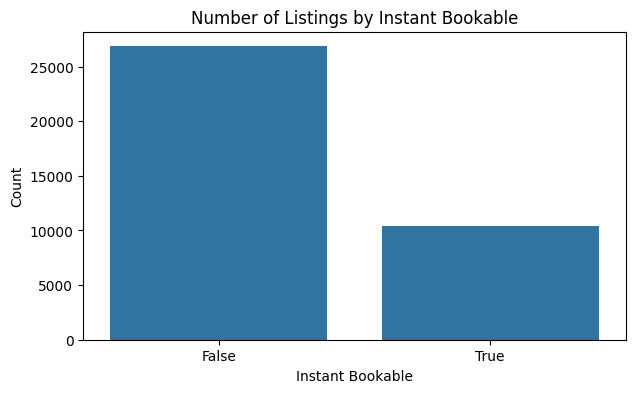

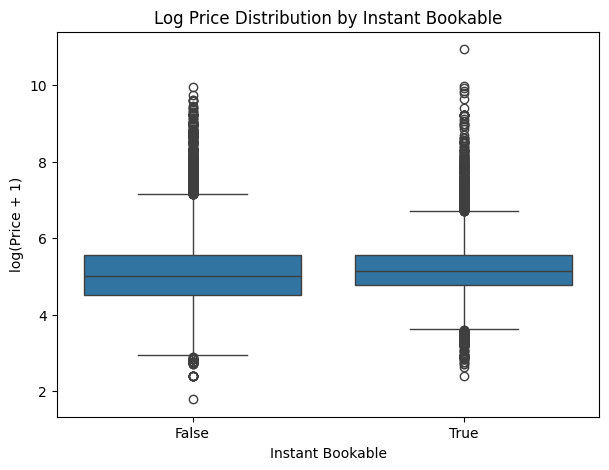

,listing_count,median_price,mean_price,median_log_price
instant_bookable,,,,
True,10445,169.0,292.935854,5.135798
False,26851,150.0,287.993669,5.017280


In [ ]:
df["instant_bookable"].value_counts(dropna=False)

plt.figure(figsize=(7,4))
sns.countplot(
    data=df,
    x="instant_bookable",
    order=df["instant_bookable"].value_counts(dropna=False).index
)
plt.title("Number of Listings by Instant Bookable")
plt.xlabel("Instant Bookable")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(7,5))
sns.boxplot(
    data=df,
    x="instant_bookable",
    y="log_price",
    order=df["instant_bookable"].value_counts(dropna=False).index
)
plt.title("Log Price Distribution by Instant Bookable")
plt.xlabel("Instant Bookable")
plt.ylabel("log(Price + 1)")
plt.show()

instant_summary = (
    df.groupby("instant_bookable", dropna=False)
    .agg(
        listing_count=("price", "count"),
        median_price=("price", "median"),
        mean_price=("price", "mean"),
        median_log_price=("log_price", "median")
    )
    .sort_values(by="median_price", ascending=False)
)

instant_summary

Most listings are not instant bookable, meaning that guests usually need host approval before booking. However, the log price distributions for instant-bookable and non-instant-bookable listings are very similar, with substantial overlap between the two groups.

This suggests that instant booking status mainly reflects booking convenience or host strategy, rather than being a strong direct pricing factor. Compared with listing capacity, room type, property type, and neighborhood, `instant_bookable` appears to have a weaker relationship with price.

5.4 License Status and Price

`license_status` reflects whether a listing has licensing or registration information. This variable may capture trust, safety, and regulatory legitimacy. In practice, guests may feel more comfortable booking listings that appear properly licensed or verified. Therefore, we examine whether license status is associated with price differences.

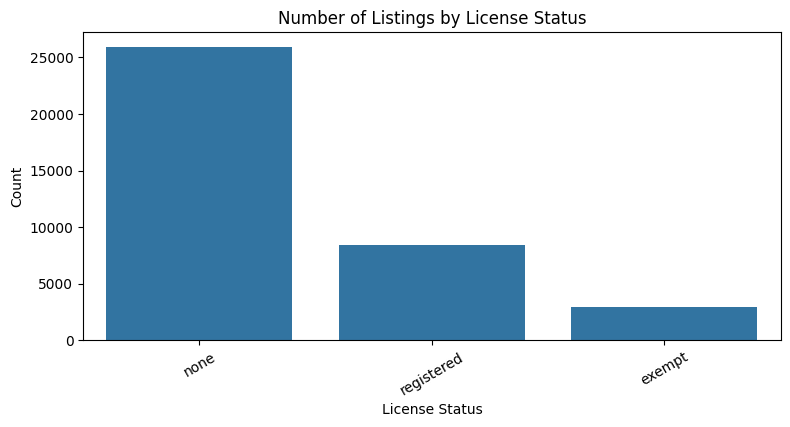

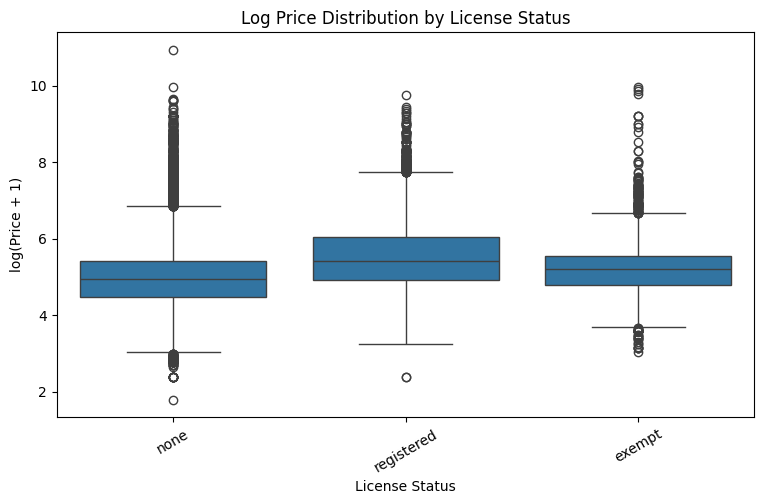

,listing_count,median_price,mean_price,median_log_price
license_status,,,,
registered,8403,222.0,418.448649,5.407172
exempt,2966,183.0,284.901214,5.214936
none,25927,140.0,248.057700,4.948760


In [ ]:
df["license_status"].value_counts(dropna=False)
plt.figure(figsize=(9,4))
sns.countplot(
    data=df,
    x="license_status",
    order=df["license_status"].value_counts(dropna=False).index
)
plt.title("Number of Listings by License Status")
plt.xlabel("License Status")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(9,5))
sns.boxplot(
    data=df,
    x="license_status",
    y="log_price",
    order=df["license_status"].value_counts(dropna=False).index
)
plt.title("Log Price Distribution by License Status")
plt.xlabel("License Status")
plt.ylabel("log(Price + 1)")
plt.xticks(rotation=30)
plt.show()

license_summary = (
    df.groupby("license_status", dropna=False)
    .agg(
        listing_count=("price", "count"),
        median_price=("price", "median"),
        mean_price=("price", "mean"),
        median_log_price=("log_price", "median")
    )
    .sort_values(by="median_price", ascending=False)
)

license_summary

License status shows a clearer relationship with price than the other host-related variables. Registered listings have the highest median price at 222 USD, followed by exempt listings at 183 USD, while listings with no license status have the lowest median price at 140 USD.

This pattern suggests that license status may capture trust, safety, and regulatory legitimacy. Guests may be more willing to pay higher prices for listings that appear properly registered or compliant. In contrast, listings with no license status may be perceived as less formal or less reliable, which could be associated with lower prices.

However, license status should not be interpreted as a causal factor by itself. Registered listings may also differ from unlicensed listings in other ways, such as property type, location, listing quality, or host professionalism. Therefore, license status is best understood as a trust-related feature that may provide useful additional information for later clustering and supervised price prediction.

Host, Trust, and Booking Characteristics Summary

Overall, most host and booking-related variables show weaker relationships with price compared with listing capacity, room type, property type, and neighborhood. Superhost status, host response time, and instant booking status show substantial overlap in price distributions, suggesting that they are not strong direct pricing factors.

However, license status shows a more noticeable difference. Registered listings have a higher median price than exempt listings and listings with no license status. This suggests that regulatory legitimacy, trust, and perceived safety may be associated with higher listing prices.

Therefore, host-related variables may not be the primary drivers of Airbnb prices, but some trust-related features, especially `license_status`, may still provide useful information for understanding price differences and for later clustering or prediction.

## 6. Review and Demand Features
In this section, we examine review-related and demand-related variables, including `number_of_reviews`, `review_scores_rating`, `availability_365`, and `minimum_nights`. These variables may capture listing popularity, guest satisfaction, booking activity, and host booking policies.

Unlike listing capacity or property type, these variables may have more complex relationships with price. For example, a high number of reviews may indicate popularity, but it may also reflect older or more affordable listings that receive frequent bookings.

6.1 Number of Reviews vs Price

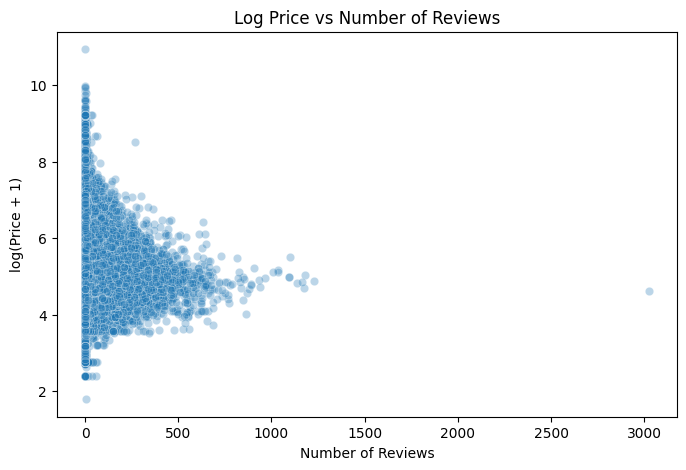

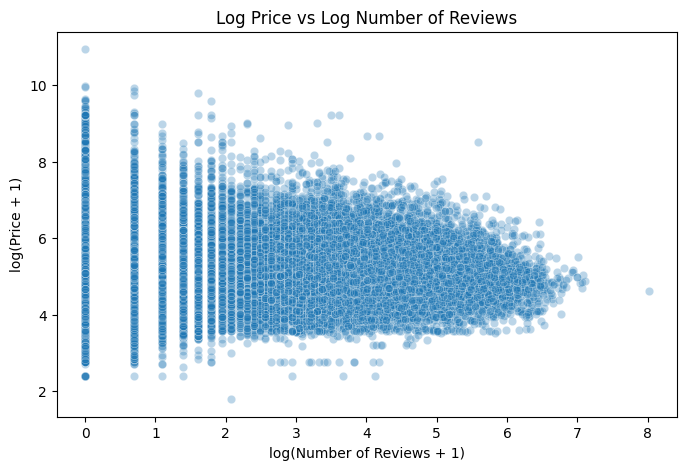

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="number_of_reviews",
    y="log_price",
    alpha=0.3
)
plt.title("Log Price vs Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("log(Price + 1)")
plt.show()

df["log_number_of_reviews"] = np.log1p(df["number_of_reviews"])

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="log_number_of_reviews",
    y="log_price",
    alpha=0.3
)
plt.title("Log Price vs Log Number of Reviews")
plt.xlabel("log(Number of Reviews + 1)")
plt.ylabel("log(Price + 1)")
plt.show()

The scatterplots do not show a strong positive relationship between number of reviews and log price. Listings with many reviews are not necessarily more expensive.


6.2 Review Score Rating vs Price


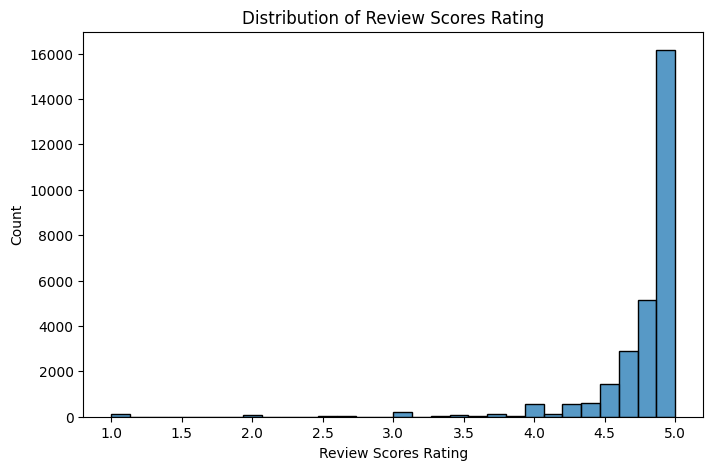

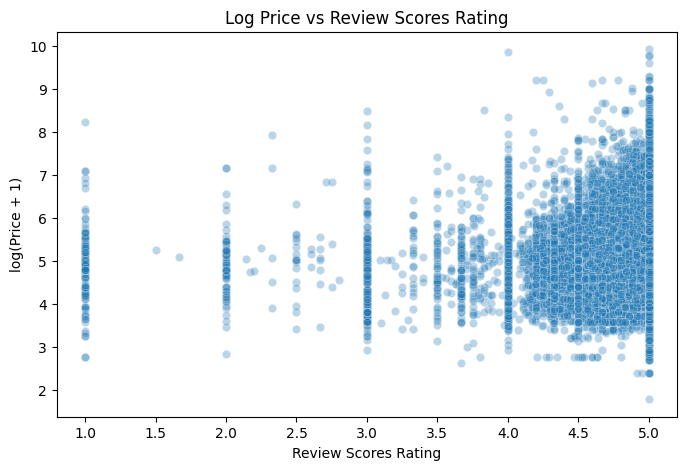

In [ ]:
df["review_scores_rating"].isnull().sum()

plt.figure(figsize=(8,5))
sns.histplot(df["review_scores_rating"].dropna(), bins=30)
plt.title("Distribution of Review Scores Rating")
plt.xlabel("Review Scores Rating")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="review_scores_rating",
    y="log_price",
    alpha=0.3
)
plt.title("Log Price vs Review Scores Rating")
plt.xlabel("Review Scores Rating")
plt.ylabel("log(Price + 1)")
plt.show()

Review scores are highly concentrated near the upper end of the rating scale, especially between 4.5 and 5.0. This suggests that most reviewed listings have relatively high guest ratings, leaving limited variation for distinguishing high-price and low-price listings.

The scatterplot does not show a clear relationship between review score and log price. Listings with higher ratings are not necessarily more expensive, and prices vary widely even among listings with similar ratings. Therefore, `review_scores_rating` does not appear to be a strong direct pricing factor.

This variable may still provide useful information about guest satisfaction and listing quality, but its predictive value may be limited because of rating concentration and missing values.

6.3 Availability 365 and Price

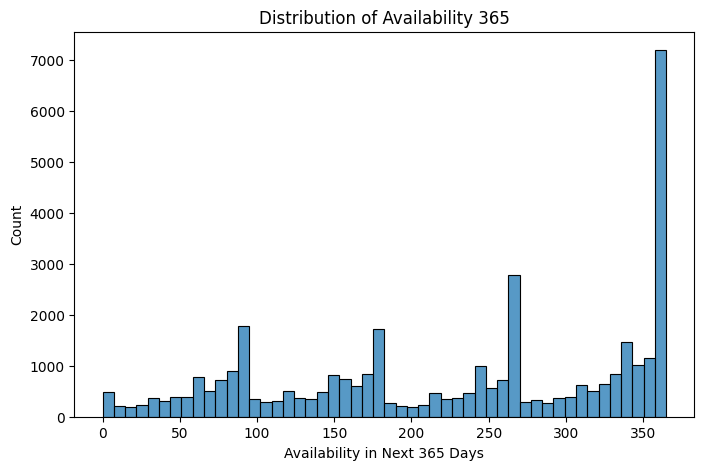

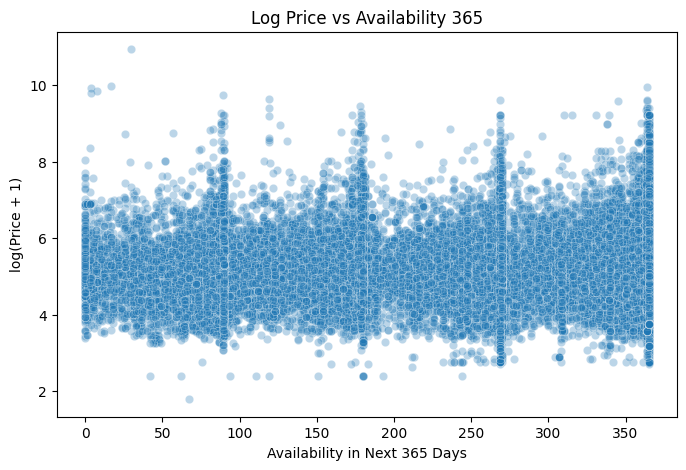

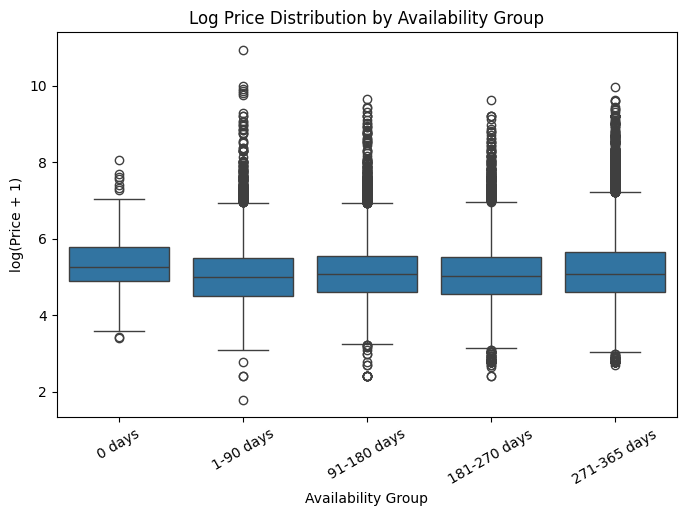

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["availability_365"], bins=50)
plt.title("Distribution of Availability 365")
plt.xlabel("Availability in Next 365 Days")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="availability_365",
    y="log_price",
    alpha=0.3
)
plt.title("Log Price vs Availability 365")
plt.xlabel("Availability in Next 365 Days")
plt.ylabel("log(Price + 1)")
plt.show()

def availability_group(x):
    if x == 0:
        return "0 days"
    elif x <= 90:
        return "1-90 days"
    elif x <= 180:
        return "91-180 days"
    elif x <= 270:
        return "181-270 days"
    else:
        return "271-365 days"

df["availability_group"] = df["availability_365"].apply(availability_group)

availability_order = ["0 days", "1-90 days", "91-180 days", "181-270 days", "271-365 days"]

availability_summary = (
    df.groupby("availability_group")
    .agg(
        listing_count=("price", "count"),
        median_price=("price", "median"),
        mean_price=("price", "mean"),
        median_log_price=("log_price", "median")
    )
    .reindex(availability_order)
)

availability_summary

plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="availability_group",
    y="log_price",
    order=availability_order
)
plt.title("Log Price Distribution by Availability Group")
plt.xlabel("Availability Group")
plt.ylabel("log(Price + 1)")
plt.xticks(rotation=30)
plt.show()

The scatterplot does not show a clear linear relationship between `availability_365` and log price. Listings with higher availability are not consistently more expensive or cheaper, and prices are widely spread across the full range of availability values.

The grouped boxplot also shows that median log prices are relatively similar across availability groups. Listings with 0 available days appear to have a slightly higher median log price, but this pattern should be interpreted carefully. A listing with low availability may indicate strong demand, limited host availability, or temporary unavailability, so availability does not directly measure listing quality or price level.

Overall, `availability_365` may provide useful information about booking activity, host strategy, and supply, but it does not appear to be a strong direct pricing factor compared with capacity, room type, property type, or neighborhood.

6.4 Minimum Nights and Price

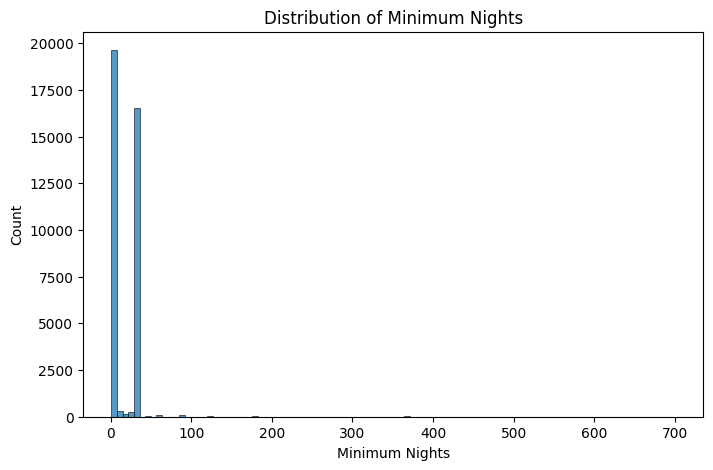

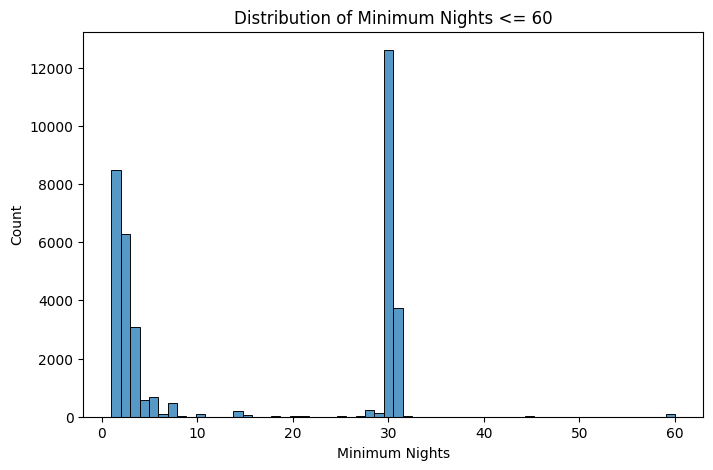

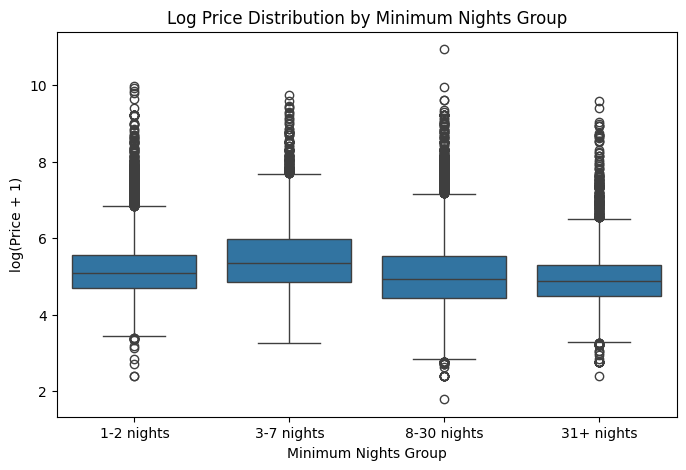

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["minimum_nights"], bins=100)
plt.title("Distribution of Minimum Nights")
plt.xlabel("Minimum Nights")
plt.ylabel("Count")
plt.show()

df_min_nights_filtered = df[df["minimum_nights"] <= 60].copy()

plt.figure(figsize=(8,5))
sns.histplot(df_min_nights_filtered["minimum_nights"], bins=60)
plt.title("Distribution of Minimum Nights <= 60")
plt.xlabel("Minimum Nights")
plt.ylabel("Count")
plt.show()

def minimum_nights_group(x):
    if x <= 2:
        return "1-2 nights"
    elif x <= 7:
        return "3-7 nights"
    elif x <= 30:
        return "8-30 nights"
    else:
        return "31+ nights"

df["minimum_nights_group"] = df["minimum_nights"].apply(minimum_nights_group)

min_nights_order = ["1-2 nights", "3-7 nights", "8-30 nights", "31+ nights"]

min_nights_summary = (
    df.groupby("minimum_nights_group")
    .agg(
        listing_count=("price", "count"),
        median_price=("price", "median"),
        mean_price=("price", "mean"),
        median_log_price=("log_price", "median")
    )
    .reindex(min_nights_order)
)

min_nights_summary

plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="minimum_nights_group",
    y="log_price",
    order=min_nights_order
)
plt.title("Log Price Distribution by Minimum Nights Group")
plt.xlabel("Minimum Nights Group")
plt.ylabel("log(Price + 1)")
plt.show()

The distribution of `minimum_nights` is highly skewed. Most listings require relatively short stays, especially between 1 and 3 nights, while there is also a noticeable concentration around 30 nights. This may reflect different host strategies, such as short-term tourist rentals versus monthly or medium-term rental arrangements.

The grouped boxplot shows some price differences across minimum-night groups. Listings requiring 3-7 nights appear to have a slightly higher median log price, while longer minimum-stay listings do not necessarily have higher prices. However, the price distributions overlap substantially across all groups.

This suggests that `minimum_nights` captures host booking policy rather than listing quality directly. It may still be useful as a secondary feature for clustering and supervised modeling, but it is not as strong a direct pricing factor as capacity, room type, property type, or neighborhood.

Review and Demand Features Summary

Overall, review and demand-related variables show weaker and more complex relationships with price than listing capacity, room type, property type, and neighborhood.

`number_of_reviews` does not show a strong positive relationship with price. Highly reviewed listings are not necessarily more expensive, suggesting that review count may reflect listing activity, popularity, or listing age rather than premium pricing.

`review_scores_rating` is highly concentrated near the upper end of the rating scale, which limits its ability to separate high-price and low-price listings. `availability_365` also does not show a clear linear relationship with price, although it may capture booking activity, supply, or host strategy.

Among these variables, `minimum_nights` provides some useful information about booking policy. The clear concentration around short stays and 30-night stays suggests different rental strategies. However, the relationship with price is still moderate and should be interpreted as secondary compared with the stronger pricing factors identified earlier.

## 7. Overall Correlation Analysis

7.1 Numeric Variables

In [ ]:
# Create log-transformed number of reviews if not already created
df["log_number_of_reviews"] = np.log1p(df["number_of_reviews"])

numeric_cols = [
    "log_price",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "availability_365",
    "number_of_reviews",
    "log_number_of_reviews",
    "review_scores_rating",
    "host_response_rate",
    "latitude",
    "longitude"
]

# Keep only columns that exist in the dataframe
numeric_cols = [col for col in numeric_cols if col in df.columns]

df_corr = df[numeric_cols].copy()
df_corr.head()

,log_price,accommodates,bathrooms,bedrooms,beds,minimum_nights,availability_365,number_of_reviews,log_number_of_reviews,review_scores_rating,host_response_rate,latitude,longitude
0,5.991465,6,3.0,3.0,3.0,30,365,0,0.000000,NaN,0.96,34.049660,-118.435550
1,6.075346,6,3.0,3.0,3.0,30,267,0,0.000000,NaN,0.60,34.070583,-118.390742
2,3.912023,2,1.0,1.0,1.0,1,364,1,0.693147,3.00,0.20,34.109329,-118.073098
3,5.446737,2,1.0,0.0,1.0,5,193,44,3.806662,4.93,1.00,34.015590,-118.494080
4,4.143135,1,0.0,4.0,1.0,30,278,0,0.000000,NaN,1.00,34.173990,-118.361840


7.2 Heat Map

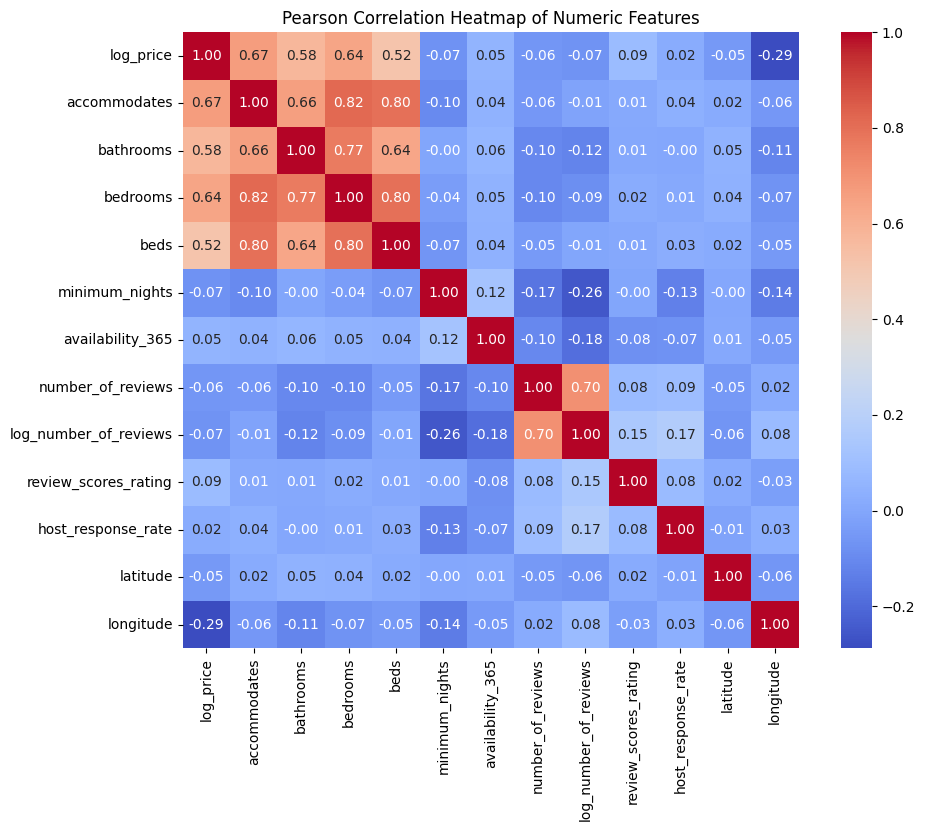

In [ ]:
pearson_corr = df_corr.corr(method="pearson")

plt.figure(figsize=(11, 8))
sns.heatmap(
    pearson_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)
plt.title("Pearson Correlation Heatmap of Numeric Features")
plt.show()

In [ ]:
pearson_with_price = (
    df_corr
    .corr(method="pearson")["log_price"]
    .drop("log_price")
)

spearman_with_price = (
    df_corr
    .corr(method="spearman")["log_price"]
    .drop("log_price")
)

corr_with_price = pd.DataFrame({
    "Pearson_with_log_price": pearson_with_price,
    "Spearman_with_log_price": spearman_with_price
})

corr_with_price["Abs_Spearman"] = corr_with_price["Spearman_with_log_price"].abs()

corr_with_price = corr_with_price.sort_values(
    by="Abs_Spearman",
    ascending=False
)

corr_with_price

,Pearson_with_log_price,Spearman_with_log_price,Abs_Spearman
accommodates,0.666928,0.712544,0.712544
bedrooms,0.638377,0.657169,0.657169
beds,0.519136,0.622535,0.622535
bathrooms,0.576752,0.572607,0.572607
longitude,-0.287901,-0.287444,0.287444
review_scores_rating,0.087491,0.121367,0.121367
minimum_nights,-0.074371,-0.087303,0.087303
host_response_rate,0.019498,0.057853,0.057853
number_of_reviews,-0.058834,-0.043682,0.043682
log_number_of_reviews,-0.068044,-0.043682,0.043682


Among the numeric variables, capacity-related features show the strongest positive correlations with `log_price`. Specifically, `accommodates`, `bedrooms`, `bathrooms`, and `beds` are all positively correlated with log price. This supports the earlier EDA finding that larger listings tend to have higher prices.

In contrast, review and demand-related variables such as `number_of_reviews`, `review_scores_rating`, `availability_365`, and `minimum_nights` show weak correlations with `log_price`, which is consistent with the earlier scatterplots.

For location, `latitude` and `longitude` are included as numeric variables, but detailed neighborhood categories are not included in this heatmap. The earlier neighborhood-level analysis showed that specific neighborhoods provide more meaningful location information than broad numeric coordinates alone.

## 8. EDA Summary and Modeling Implications

Based on the exploratory data analysis, several groups of variables appear to be useful for understanding Airbnb listing prices in Los Angeles.

First, listing capacity variables show the strongest numeric relationship with price. `accommodates`, `bedrooms`, `beds`, and `bathrooms` have the highest Pearson and Spearman correlations with `log_price`, and the boxplots also show that larger listings generally have higher prices. These variables should be considered important predictors in later supervised modeling and useful inputs for unsupervised clustering.

Second, categorical listing characteristics are also important. `room_type` shows clear median price differences across hotel rooms, entire homes/apartments, private rooms, and shared rooms. `property_type` also shows meaningful price differences, especially between premium property types such as entire villas and lower-price private-room categories.

Third, location matters. Specific neighborhoods show much clearer differences in median price. Therefore, `neighbourhood_cleansed` is likely useful.

Fourth, host and trust-related variables show mixed results. `host_is_superhost`, `host_response_time`, and `instant_bookable` show relatively weak price differences. However, `license_status` shows a clearer pattern: registered listings have a higher median price than exempt listings and listings with no license status. This suggests that license status may capture trust, safety, or regulatory legitimacy.

Fifth, review and demand-related variables show weaker and more complex relationships with price. `number_of_reviews`, `review_scores_rating`, `availability_365`, and `minimum_nights` do not show strong direct correlations with price. These variables may still be useful as secondary features because they capture listing activity, guest feedback, host policy, or booking strategy.

Overall, the strongest candidate features for price prediction are listing capacity, room type, property type, detailed neighborhood, and license status. Review, demand, and host behavior variables may be included as secondary features, but they are less likely to be primary price drivers.

##9. Unsupervised Learning
We use K-Means clustering as the main unsupervised learning model.

We firstly use PCA for visualization. After preprocessing the selected features, we fit K-Means and evaluate different values of k using inertia, the elbow method, silhouette score, cluster size balance, and interpretability.

Price and log price are excluded from the clustering inputs. After clusters are formed, we compare price distributions across clusters to examine whether the identified listing profiles are associated with different price levels.

9.1 Feature Selection for Clustering

Based on the EDA results, we select core listing features for clustering. These features include listing capacity, room type, property type, detailed neighborhood, and license status.

We exclude `price` and `log_price` from the clustering inputs because the goal is to group listings based on their characteristics rather than directly by price. Price will only be used after clustering to compare price distributions across clusters.

We also exclude weaker host-behavior and review/demand variables from the main clustering model to reduce noise and improve interpretability.

In [32]:
cluster_features = [
    # Capacity features
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",

    # Listing type and location
    "room_type",
    "property_type",
    "neighbourhood_cleansed",

    # Trust / regulation
    "license_status"
]

# Keep only columns that exist in the dataframe
cluster_features = [col for col in cluster_features if col in df.columns]

X_cluster = df[cluster_features].copy()

print("Selected clustering features:")
print(cluster_features)

print("\nShape of clustering dataset:")
print(X_cluster.shape)

print("\nMissing values in selected features:")
print(X_cluster.isnull().sum().sort_values(ascending=False))

X_cluster.head()

Selected clustering features:
['accommodates', 'bathrooms', 'bedrooms', 'beds', 'room_type', 'property_type', 'neighbourhood_cleansed', 'license_status']

Shape of clustering dataset:
(37296, 8)

Missing values in selected features:
beds                      906
bedrooms                  145
bathrooms                  12
accommodates                0
room_type                   0
property_type               0
neighbourhood_cleansed      0
license_status              0
dtype: int64


,accommodates,bathrooms,bedrooms,beds,room_type,property_type,neighbourhood_cleansed,license_status
0,6,3.0,3.0,3.0,Entire home/apt,Entire condo,West Los Angeles,none
1,6,3.0,3.0,3.0,Entire home/apt,Entire home,Beverly Hills,none
2,2,1.0,1.0,1.0,Private room,Private room in home,Temple City,none
3,2,1.0,0.0,1.0,Entire home/apt,Entire rental unit,Santa Monica,exempt
4,1,0.0,4.0,1.0,Private room,Private room in rental unit,North Hollywood,none


The selected clustering dataset contains 37,296 listings and 8 core features. These features were selected based on the EDA results because they capture listing capacity, listing type, detailed neighborhood, and license status.

Among the selected features, only `beds`, `bedrooms`, and `bathrooms` contain missing values. Since the missing counts are relatively small compared with the full sample size, we do not drop these observations. Instead, missing numeric values will be imputed during preprocessing.

Categorical features such as `room_type`, `property_type`, `neighbourhood_cleansed`, and `license_status` have no missing values in the selected clustering dataset.

9.2 Preprocessing for K-Means

K-Means is distance-based, so all selected features need to be transformed into a numeric feature matrix. Numeric variables are imputed using the median and standardized. Categorical variables are imputed using the most frequent category and then one-hot encoded. Rare categories are grouped to reduce dimensionality.

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_features = X_cluster.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_cluster.select_dtypes(include=["object", "bool"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# Handle different sklearn versions for OneHotEncoder
try:
    ohe = OneHotEncoder(
        handle_unknown="ignore",
        min_frequency=30,
        sparse_output=False
    )
except TypeError:
    ohe = OneHotEncoder(
        handle_unknown="ignore",
        min_frequency=30,
        sparse=False
    )

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_processed = preprocessor.fit_transform(X_cluster)

print("Original shape:", X_cluster.shape)
print("Processed shape:", X_processed.shape)

Numeric features: ['accommodates', 'bathrooms', 'bedrooms', 'beds']
Categorical features: ['room_type', 'property_type', 'neighbourhood_cleansed', 'license_status']
Original shape: (37296, 8)
Processed shape: (37296, 220)


After preprocessing, the original 8 selected clustering variables are transformed into 220 numeric features. This increase in dimensionality is due to one-hot encoding of categorical variables such as `property_type` and `neighbourhood_cleansed`.

Numeric variables are imputed and standardized, while categorical variables are imputed and one-hot encoded. This produces a complete numeric feature matrix that can be used for PCA visualization and K-Means clustering.

9.3 K-Means on X_processed

In [37]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_range = range(2, 9)

inertia_A = []
silhouette_A = []

sample_size = min(5000, X_processed.shape[0])
sample_indices = np.random.RandomState(42).choice(
    X_processed.shape[0],
    size=sample_size,
    replace=False
)
X_sample_A = X_processed[sample_indices]

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_processed)
    inertia_A.append(kmeans.inertia_)

    sample_labels = labels[sample_indices]
    silhouette_A.append(silhouette_score(X_sample_A, sample_labels))

pipeline_A_results = pd.DataFrame({
    "k": list(K_range),
    "inertia": inertia_A,
    "silhouette": silhouette_A
})

pipeline_A_results

,k,inertia,silhouette
0,2,162782.830794,0.365235
1,3,142539.080482,0.211734
2,4,128301.049863,0.184080
3,5,120397.206692,0.160508
4,6,115688.210310,0.148892
5,7,111254.460249,0.145468
6,8,108009.933965,0.133455


From the silhouette table above, k=2 is the best.

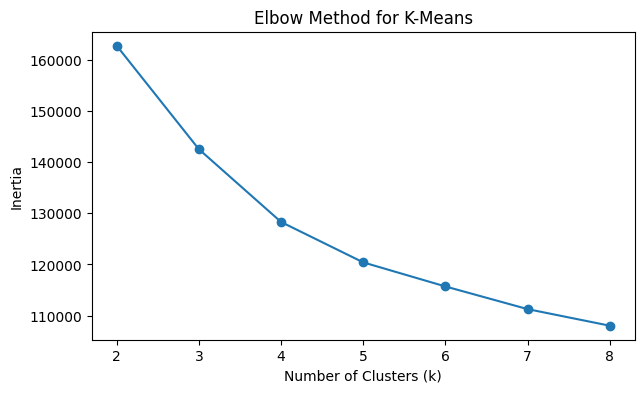

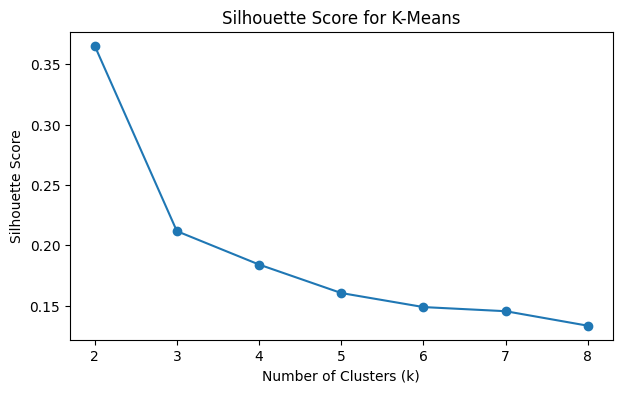

In [38]:
plt.figure(figsize=(7,4))
plt.plot(pipeline_A_results["k"], pipeline_A_results["inertia"], marker="o")
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

plt.figure(figsize=(7,4))
plt.plot(pipeline_A_results["k"], pipeline_A_results["silhouette"], marker="o")
plt.title("Silhouette Score for K-Means")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()



The silhouette diagram also shows that the score drops significantly from k=2 to k=3, which means k=2 is the best.

In [41]:
# Fit final K-Means model with k = 2
final_k = 2

kmeans_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
df["cluster"] = kmeans_final.fit_predict(X_processed)

# Cluster size
df["cluster"].value_counts().sort_index()

cluster_price_summary = (
    df.groupby("cluster")
    .agg(
        listing_count=("price", "count"),
        median_price=("price", "median"),
        mean_price=("price", "mean"),
        median_log_price=("log_price", "median")
    )
    .round(2)
)

cluster_price_summary


,listing_count,median_price,mean_price,median_log_price
cluster,,,,
0,9404,350.0,645.84,5.86
1,27892,126.0,169.19,4.84


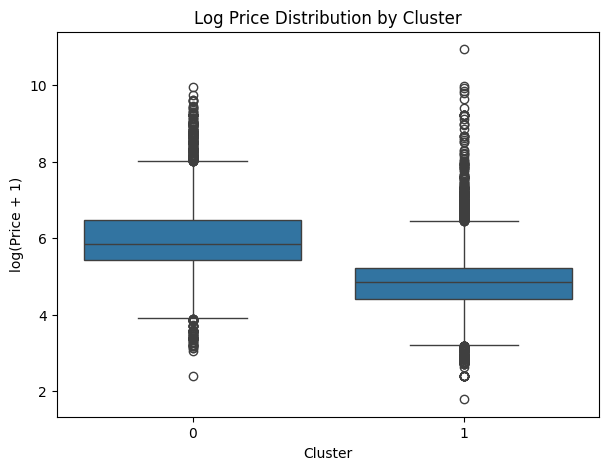

In [42]:
plt.figure(figsize=(7,5))
sns.boxplot(
    data=df,
    x="cluster",
    y="log_price"
)
plt.title("Log Price Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("log(Price + 1)")
plt.show()

The cluster outcome and the cluster box plot both suggest that k=2 clusters show a clear difference in price distribution.

9.6 Cluster Profiling

After identifying two clusters, we profile each cluster using the original interpretable features. This helps us understand what types of listings each cluster represents. We compare capacity variables, room type, property type, neighborhood, and license status across clusters.

a. Capacity Profiling

In [43]:
cluster_capacity_summary = (
    df.groupby("cluster")
    .agg(
        listing_count=("price", "count"),
        median_price=("price", "median"),
        mean_price=("price", "mean"),
        avg_accommodates=("accommodates", "mean"),
        avg_bathrooms=("bathrooms", "mean"),
        avg_bedrooms=("bedrooms", "mean"),
        avg_beds=("beds", "mean")
    )
    .round(2)
)

cluster_capacity_summary

,listing_count,median_price,mean_price,avg_accommodates,avg_bathrooms,avg_bedrooms,avg_beds
cluster,,,,,,,
0,9404,350.0,645.84,8.11,3.00,3.60,4.52
1,27892,126.0,169.19,2.85,1.19,1.16,1.55


The two clusters show a clear difference in listing capacity. Cluster 0 contains fewer listings but has much higher average capacity: it accommodates about 8 guests on average, with around 3 bathrooms, 3.6 bedrooms, and 4.5 beds. Its median price is also much higher at $350.

In contrast, Cluster 1 contains the majority of listings and represents smaller listings. It accommodates about 2.9 guests on average, with around 1.2 bathrooms, 1.2 bedrooms, and 1.6 beds. Its median price is much lower at $126.

This suggests that K-Means identified a meaningful size-based segmentation: Cluster 0 represents larger, higher-price listings, while Cluster 1 represents smaller, more affordable listings.

b. room type profile

For all later on categorical profiling, we use the proportion analysis relative their respective clusters and compare each other.

In [44]:
room_type_cluster = pd.crosstab(
    df["cluster"],
    df["room_type"],
    normalize="index"
).round(3)

room_type_cluster

room_type,Entire home/apt,Hotel room,Private room,Shared room
cluster,,,,
0,0.977,0.003,0.012,0.007
1,0.703,0.003,0.279,0.016


The room type composition further supports the interpretation of the two clusters. Cluster 0 is almost entirely composed of entire home/apartment listings, with 97.7% of listings in this category. This aligns with its larger average capacity and higher median price.

Cluster 1 is more mixed. Although entire home/apartment listings still make up the majority, private rooms account for 27.9% of the cluster, which is much higher than in Cluster 0. This helps explain why Cluster 1 has lower average capacity and a lower median price.

Overall, Cluster 0 represents a premium entire-home segment, while Cluster 1 represents a more affordable and mixed listing segment that includes many smaller private-room listings.

c. Property Type Profile


In [45]:
for c in sorted(df["cluster"].unique()):
    print(f"\nCluster {c} - Top Property Types")
    display(
        df[df["cluster"] == c]["property_type"]
        .value_counts(normalize=True)
        .head(10)
        .round(3)
    )


Cluster 0 - Top Property Types


,proportion
property_type,
Entire home,0.741
Entire rental unit,0.076
Entire villa,0.062
Entire townhouse,0.043
Entire condo,0.025
Entire bungalow,0.006
Entire serviced apartment,0.005
Shared room in home,0.005
Entire guesthouse,0.005



Cluster 1 - Top Property Types


,proportion
property_type,
Entire rental unit,0.316
Private room in home,0.163
Entire home,0.144
Entire guesthouse,0.087
Private room in rental unit,0.048
Entire condo,0.044
Entire guest suite,0.041
Entire bungalow,0.013
Entire serviced apartment,0.013


The property type profile further distinguishes the two clusters. Cluster 0 is highly concentrated in entire-property listings. About 74.1% of listings in Cluster 0 are `Entire home`, followed by smaller shares of `Entire rental unit`, `Entire villa`, `Entire townhouse`, and `Entire condo`. This supports the interpretation that Cluster 0 represents larger, whole-property listings with higher capacity and higher prices.

Cluster 1 is more mixed. Its most common property type is `Entire rental unit`, but it also contains a substantial share of `Private room in home`, `Entire home`, `Entire guesthouse`, and other smaller property types. This aligns with its lower average capacity and lower median price.

Overall, Cluster 0 can be interpreted as a premium high-capacity entire-home segment, while Cluster 1 represents a broader and more affordable mixed-listing segment.

d. License Status

In [46]:
license_cluster = pd.crosstab(
    df["cluster"],
    df["license_status"],
    normalize="index"
).round(3)

license_cluster

license_status,exempt,none,registered
cluster,,,
0,0.058,0.590,0.352
1,0.087,0.731,0.182


The license status profile shows another difference between the two clusters. Cluster 0 has a higher share of registered listings: 35.2% of listings in Cluster 0 are registered, compared with only 18.2% in Cluster 1. Cluster 0 also has a lower share of listings with no license status information.

In contrast, Cluster 1 has a higher share of `none` license status, with 73.1% of listings falling into this category. In this dataset, `none` should be interpreted as no recorded license status or no available registration information.

This supports the interpretation that Cluster 0 represents a more formal, high-capacity, premium listing segment, while Cluster 1 represents a broader and more affordable mixed-listing segment with less visible license registration information.

e. Neighborhood Profile

In [47]:
for c in sorted(df["cluster"].unique()):
    print(f"\nCluster {c} - Top Neighborhoods")
    display(
        df[df["cluster"] == c]["neighbourhood_cleansed"]
        .value_counts(normalize=True)
        .head(10)
        .round(3)
        .to_frame("proportion")
    )


Cluster 0 - Top Neighborhoods


,proportion
neighbourhood_cleansed,
Long Beach,0.041
Hollywood Hills West,0.039
Venice,0.036
Beverly Hills,0.034
Malibu,0.028
Woodland Hills,0.021
Hollywood Hills,0.020
Hollywood,0.020
Sherman Oaks,0.020



Cluster 1 - Top Neighborhoods


,proportion
neighbourhood_cleansed,
Long Beach,0.043
Santa Monica,0.042
Hollywood,0.040
Venice,0.035
Beverly Hills,0.035
Downtown,0.029
West Hollywood,0.029
Glendale,0.021
Pasadena,0.017


In [58]:
neigh_cluster_prop = pd.crosstab(
    df["neighbourhood_cleansed"],
    df["cluster"],
    normalize="columns"
).round(4)

neigh_cluster_prop["cluster_0_minus_cluster_1"] = (
    neigh_cluster_prop[0] - neigh_cluster_prop[1]
)

neigh_cluster_prop.sort_values(
    "cluster_0_minus_cluster_1",
    ascending=False
).head(15)

cluster,0,1,cluster_0_minus_cluster_1
neighbourhood_cleansed,,,
Hollywood Hills West,0.0395,0.0069,0.0326
Malibu,0.0285,0.0051,0.0234
Beverly Crest,0.0148,0.0017,0.0131
Sherman Oaks,0.0201,0.0084,0.0117
Woodland Hills,0.0213,0.0097,0.0116
Encino,0.0113,0.0034,0.0079
Manhattan Beach,0.0142,0.0076,0.0066
Studio City,0.0137,0.0072,0.0065
Unincorporated Santa Monica Mountains,0.0095,0.0031,0.0064


The neighborhood comparison focuses on the top 15 neighborhoods with the largest difference between Cluster 0 and Cluster 1. Cluster 0 has relatively higher proportions in neighborhoods such as Hollywood Hills West, Malibu, Beverly Crest, Sherman Oaks, Woodland Hills, Encino, Manhattan Beach, Studio City, and Bel-Air. These areas are consistent with higher-end residential or coastal/hillside listing markets.

However, neighborhood does not create a perfectly clean geographic separation because many neighborhoods still appear in both clusters. Therefore, neighborhood should be interpreted as a supporting feature rather than the primary driver of the clustering result. The strongest separation between the two clusters still comes from listing capacity, room type, and property type.

### 9.7 Unsupervised Learning Summary

K-Means clustering identifies two meaningful Airbnb listing profiles in Los Angeles.

Cluster 0 represents a premium high-capacity entire-home segment. Listings in this cluster have a much higher median price, larger guest capacity, more bedrooms, more bathrooms, and more beds. This cluster is also dominated by entire home/apartment listings and has a higher share of registered license status. Its neighborhood profile is relatively more associated with higher-end residential, coastal, and hillside listing markets.

Cluster 1 represents a smaller, more mixed, and more affordable listing segment. It contains the majority of listings, has lower average capacity, lower median price, and a higher share of private rooms or smaller rental units. It also has a higher share of listings without recorded license information.

Overall, the unsupervised learning result supports the EDA findings. The main factors separating Airbnb listing profiles are listing capacity, room type, property type, and license status. Neighborhood provides some supporting geographic pattern, but it is not the primary driver of the clustering result.

In [59]:
cluster_final_summary = (
    df.groupby("cluster")
    .agg(
        listing_count=("price", "count"),
        median_price=("price", "median"),
        mean_price=("price", "mean"),
        avg_accommodates=("accommodates", "mean"),
        avg_bathrooms=("bathrooms", "mean"),
        avg_bedrooms=("bedrooms", "mean"),
        avg_beds=("beds", "mean"),
        top_room_type=("room_type", lambda x: x.value_counts().index[0]),
        top_property_type=("property_type", lambda x: x.value_counts().index[0]),
        top_license_status=("license_status", lambda x: x.value_counts().index[0])
    )
    .round(2)
)

cluster_final_summary

,listing_count,median_price,mean_price,avg_accommodates,avg_bathrooms,avg_bedrooms,avg_beds,top_room_type,top_property_type,top_license_status
cluster,,,,,,,,,,
0,9404,350.0,645.84,8.11,3.00,3.60,4.52,Entire home/apt,Entire home,none
1,27892,126.0,169.19,2.85,1.19,1.16,1.55,Entire home/apt,Entire rental unit,none


Although price was not used as a clustering input, the resulting clusters show a clear difference in price distribution. Cluster 0 has in average higher price than cluster 1. This suggests that the selected listing characteristics are strongly associated with Airbnb listing prices and can help explain different pricing segments in the Los Angeles Airbnb market.